In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.stats import gamma as scipy_gamma
import os
import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"

plt.close("all")

# ---------- simple linear gain+offset fit ----------
def fit_gain_offset(model, data):
    """
    Find a, b such that data ≈ a*model + b (least squares).
    NaN-safe.
    """
    model = np.asarray(model, dtype=float)
    data  = np.asarray(data,  dtype=float)
    m = np.isfinite(model) & np.isfinite(data)
    if m.sum() < 3:
        return np.nan, np.nan
    A = np.vstack([model[m], np.ones_like(model[m])]).T
    a, b = np.linalg.lstsq(A, data[m], rcond=None)[0]
    return a, b

def r2_nan(y_true, y_pred):
    """
    NaN-safe R^2.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 3:
        return np.nan
    yt = y_true[m]
    yp = y_pred[m]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    if ss_tot <= 0:
        return np.nan
    return 1.0 - ss_res / ss_tot

# ---- helper: snap limits to nearest 0.5 ----
def round_down_to_half(x):
    return 0.5 * np.floor(x / 0.5)

def round_up_to_half(x):
    return 0.5 * np.ceil(x / 0.5)

def compute_ylim_from_traces(traces):
    """
    traces: list of 1D arrays (data + model fits)
    Returns (ymin, ymax) snapped to 0.5 grid,
    strictly enclosing the data.
    """
    vals = []
    for t in traces:
        t = np.asarray(t, dtype=float)
        t = t[np.isfinite(t)]
        if t.size > 0:
            vals.append(t)

    if len(vals) == 0:
        return (-0.5, 0.5)

    vmin = min(np.min(v) for v in vals)
    vmax = max(np.max(v) for v in vals)

    lo = round_down_to_half(vmin)
    hi = round_up_to_half(vmax)

    # safety (rare edge case)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = (-0.5, 0.5)

    return (lo, hi)


In [2]:
import hashlib
import random
import numpy as np  # make sure np is in scope here

def stable_seed(*parts, base=1, mod=2**31 - 1):
    """
    Deterministic integer seed from arbitrary strings/ints.
    Stable across runs, machines, and column order.
    """
    s = "|".join(str(p) for p in parts)
    h = hashlib.md5(s.encode("utf-8")).hexdigest()
    return (base + int(h[:8], 16)) % mod

def set_all_seeds(seed: int):
    """
    Seed all RNGs you directly use.
    """
    seed = int(seed)
    np.random.seed(seed)
    random.seed(seed)


Savitzky–Golay temp smoothing: window = 31 samples (~3.10 s), polyorder = 2
Loaded: Realistic stimulus Tc25
File: /Users/sk3526/Library/CloudStorage/OneDrive-YaleUniversity/github_repos/Diaz-Garcia-and-Beagan-et-al.-2026-AFD-/AFD_modeling_Fig_2_5_S4/realitistic_stim_Tc25.csv
Time window: 30.01 – 1500.16 s
Replicates: 21
Temp smoothing sigma: 100.0 samples
dt mean = 0.1000 s


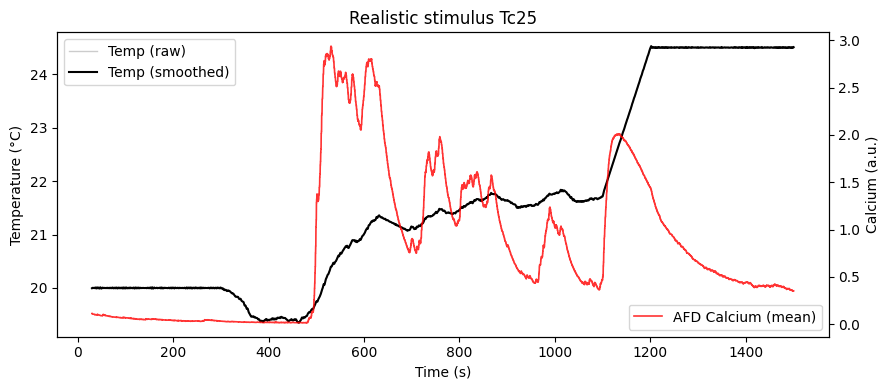

In [3]:
# ==== DROP-IN: virtual reality dataset loader (multi-replicate Rep_*),
#                WITH time-cropping AND Gaussian temp smoothing ====

# -------- USER INPUT ONLY --------
selection = 3

# Match old analysis window
T_START = 30.0
T_END   = 3000.0

# Temperature smoothing (sigma in SAMPLES)
# Recommended: 1–2 for main analysis, try 0,1,2,5 for robustness
TEMP_SMOOTH_SIGMA = 100.0
# ---------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

base_dir = "/Users/sk3526/Library/CloudStorage/OneDrive-YaleUniversity/github_repos/Diaz-Garcia-and-Beagan-et-al.-2026-AFD-/AFD_modeling_Fig_2_5_S4"

if selection == 3:
    dataset = "Realistic stimulus Tc25"
    filename = "realitistic_stim_Tc25.csv"   # or Tc25.csv
    # filename = "Tc25_test_temp.csv"   # or Tc25.csv
else:
    raise ValueError("Invalid selection. Please choose 1, 2, or 3.")

file_path = os.path.join(base_dir, filename)
df = pd.read_csv(file_path)

# ---- detect columns robustly ----
time_candidates = [c for c in df.columns if "time" in c.lower()]
temp_candidates = [c for c in df.columns if "temp" in c.lower()]
rep_cols = [c for c in df.columns if c.lower().startswith("rep")]

if len(time_candidates) == 0:
    raise ValueError(f"No time column found. Columns are: {list(df.columns)}")
if len(temp_candidates) == 0:
    raise ValueError(f"No temperature column found. Columns are: {list(df.columns)}")
if len(rep_cols) == 0:
    raise ValueError(f"No Rep_* columns found. Columns are: {list(df.columns)}")

time_col = time_candidates[0]
temp_col = temp_candidates[0]

Time_ramp = df[time_col].to_numpy(dtype=float)
Temp_raw  = df[temp_col].to_numpy(dtype=float)
Ca_mat    = df[rep_cols].to_numpy(dtype=float)  # shape (T, n_reps)

# Drop replicate columns that are all NaN
valid_rep_mask = ~np.all(np.isnan(Ca_mat), axis=0)
Ca_mat = Ca_mat[:, valid_rep_mask]
rep_cols = [c for c, ok in zip(rep_cols, valid_rep_mask) if ok]

# ============================================================
# Crop to stimulus window (CRITICAL)
# ============================================================

if T_END is None:
    mask_time = Time_ramp >= T_START
else:
    mask_time = (Time_ramp >= T_START) & (Time_ramp <= T_END)

if mask_time.sum() < 10:
    raise RuntimeError(
        f"Time crop failed: only {mask_time.sum()} points left. "
        f"Check T_START={T_START}, T_END={T_END}, "
        f"time range=[{Time_ramp.min():.2f}, {Time_ramp.max():.2f}]"
    )

Time_ramp = Time_ramp[mask_time]
Temp_raw  = Temp_raw[mask_time]
Ca_mat    = Ca_mat[mask_time, :]

# ============================================================
# Savitzky–Golay smoothing of temperature (measurement-noise only)
# Window specified in SECONDS (recommended: 3 or 5 s)
# ============================================================

from scipy.signal import savgol_filter

# -------- USER CONTROL --------
TEMP_SMOOTH_WINDOW_SEC = 3.0   # try 3.0 or 5.0
TEMP_SMOOTH_POLYORDER  = 2
# ------------------------------

# Estimate sampling interval
dt = float(np.mean(np.diff(Time_ramp)))

# Convert seconds → samples (must be odd)
win_len = int(round(TEMP_SMOOTH_WINDOW_SEC / dt))
if win_len % 2 == 0:
    win_len += 1
win_len = max(win_len, TEMP_SMOOTH_POLYORDER + 2)

print(f"Savitzky–Golay temp smoothing: window = {win_len} samples "
      f"(~{win_len*dt:.2f} s), polyorder = {TEMP_SMOOTH_POLYORDER}")

# Apply smoothing
Temp_ramp = savgol_filter(
    Temp_raw,
    window_length=win_len,
    polyorder=TEMP_SMOOTH_POLYORDER,
    mode="interp"
)

# ============================================================


n_reps = Ca_mat.shape[1]

print(f"Loaded: {dataset}")
print(f"File: {file_path}")
print(f"Time window: {Time_ramp[0]:.2f} – {Time_ramp[-1]:.2f} s")
print(f"Replicates: {n_reps}")
print(f"Temp smoothing sigma: {TEMP_SMOOTH_SIGMA} samples")
print(f"dt mean = {np.mean(np.diff(Time_ramp)):.4f} s")

# ============================================================
# Quick visualization: Temp (raw vs smoothed) + mean calcium
# ============================================================

Ca_mean = np.nanmean(Ca_mat, axis=1)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(Time_ramp, Temp_raw,  color="gray", alpha=0.4, linewidth=1.0, label="Temp (raw)")
ax1.plot(Time_ramp, Temp_ramp, "k", linewidth=1.5, label="Temp (smoothed)")

ax2.plot(Time_ramp, Ca_mean, "r", alpha=0.8, linewidth=1.2, label="AFD Calcium (mean)")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Temperature (°C)")
ax2.set_ylabel("Calcium (a.u.)")

ax1.legend(loc="upper left")
ax2.legend(loc="lower right")

plt.title(f"{dataset}")
plt.tight_layout()
plt.show()


In [4]:
# ============================================================
# STEPWISE CONCEPTUAL ANALYSIS (Option C), replicate-ready
# UPDATED: removed redundant alpha (absorbed by affine readout)
# ============================================================

optuna.logging.set_verbosity(optuna.logging.WARNING)

TAU_MIN = 1e-2
TAU_MAX = 1e3

def safe_tau(x):
    return float(np.clip(x, TAU_MIN, TAU_MAX))

def one_pole_update(prev, target, dt, tau):
    tau = safe_tau(tau)
    a = 1.0 - np.exp(-dt / tau)
    return prev + a * (target - prev)

def gamma_window(Temp, T_on, k_shape, k_scale):
    Temp = np.asarray(Temp, float)
    T_rel = np.clip(Temp - T_on, 0.0, None)
    W = scipy_gamma.pdf(T_rel, a=k_shape, scale=k_scale)
    mx = np.max(W)
    return W / (mx + 1e-9)

# ---------- UPDATED: no alpha ----------
def simulate_minimal_full(Time, Temp, tauD, T_on, k_shape, k_scale):
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    nT = Time.size
    if nT < 2:
        return np.full_like(Time, np.nan, dtype=float)

    dt = float(np.mean(np.diff(Time)))

    dT_raw = np.zeros(nT, dtype=float)
    dT_raw[1:] = np.diff(Temp) / dt

    D_state = np.zeros(nT, dtype=float)
    tauD = safe_tau(tauD)
    for i in range(1, nT):
        D_state[i] = one_pole_update(D_state[i-1], dT_raw[i], dt, tauD)

    # alpha removed: keep raw D_state (scale will be handled by affine readout)
    D = D_state
    W = gamma_window(Temp, T_on, k_shape, k_scale)
    C = D * W
    return C

# ---------- UPDATED: no alpha ----------
def model_1_derivative_gain_only(Time, Temp):
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    nT = Time.size
    if nT < 2:
        return np.full_like(Time, np.nan, dtype=float)
    dt = float(np.mean(np.diff(Time)))
    dT_raw = np.zeros(nT, dtype=float)
    dT_raw[1:] = np.diff(Temp) / dt
    return dT_raw

# ---------- UPDATED: no alpha ----------
def model_2_derivative_with_tauD(Time, Temp, tauD):
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    nT = Time.size
    if nT < 2:
        return np.full_like(Time, np.nan, dtype=float)
    dt = float(np.mean(np.diff(Time)))

    dT_raw = np.zeros(nT, dtype=float)
    dT_raw[1:] = np.diff(Temp) / dt

    D_state = np.zeros(nT, dtype=float)
    tauD = safe_tau(tauD)
    for i in range(1, nT):
        D_state[i] = one_pole_update(D_state[i-1], dT_raw[i], dt, tauD)

    return D_state

def model_3_full_minimal_gamma(Time, Temp, tauD, T_on, k_shape, k_scale):
    return simulate_minimal_full(Time, Temp, tauD, T_on, k_shape, k_scale)

class MinimalConceptObjective:
    def __init__(self, Time, Temp, Calcium, concept_id):
        self.Time = np.asarray(Time, dtype=float)
        self.Temp = np.asarray(Temp, dtype=float)
        self.Calcium = np.asarray(Calcium, dtype=float)
        self.concept_id = concept_id

        t0 = float(self.Time[0])
        self.mask = self.Time >= (t0 + 10.0)

    def __call__(self, trial):
        if self.concept_id == "deriv_gain":
            C_model = model_1_derivative_gain_only(self.Time, self.Temp)

        elif self.concept_id == "deriv_tau":
            tauD = trial.suggest_float("tauD", 0.5, 100.0, log=True)
            C_model = model_2_derivative_with_tauD(self.Time, self.Temp, tauD)

        elif self.concept_id == "full_gamma":
            tauD    = trial.suggest_float("tauD",    40.0, 60.0, log=True) # 1 to 80
            T_on    = trial.suggest_float("T_on",   20.0, 21.0) #12 to 22
            k_shape = trial.suggest_float("k_shape", 1.5, 8.0)
            k_scale = trial.suggest_float("k_scale", 0.2, 5.0)

            C_model = model_3_full_minimal_gamma(
                self.Time, self.Temp,
                tauD, T_on, k_shape, k_scale
            )
        else:
            return -1e9

        if (not np.all(np.isfinite(C_model))) or (np.nanstd(C_model) < 1e-12):
            return -1e9

        mask = self.mask
        a, b = fit_gain_offset(C_model[mask], self.Calcium[mask])
        if (not np.isfinite(a)) or (not np.isfinite(b)):
            return -1e9

        C_fit = a * C_model + b
        score = r2_nan(self.Calcium[mask], C_fit[mask])
        if not np.isfinite(score):
            return -1e9

        return float(score)

stepwise_concepts = [
    {"id": "deriv_gain", "name": "Model A"},
    {"id": "deriv_tau",  "name": "Model B"},
    {"id": "full_gamma", "name": "Model C"},
]


In [5]:
# ============================================================
# Run stepwise conceptual fits per replicate (Option 2)
# UPDATED:
#   - removed redundant alpha
#   - collect full-gamma best-fit parameters across replicates
#   - NEW: also collect Model B (deriv_tau) best-fit tauD across replicates
# ============================================================

N_TRIALS_PER_MODEL = 300
SEED_BASE = 1

Time = np.asarray(Time_ramp, dtype=float)
Temp = np.asarray(Temp_ramp, dtype=float)

r2_by_concept = {cfg["id"]: [] for cfg in stepwise_concepts}

representative = None
best_full_gamma_r2 = -1e9

# ---- store full-gamma best-fit params across replicates (Model C only) ----
all_full_params = []   # one row per replicate (full model only)

# ---- NEW: store Model B best-fit params across replicates (Model B only) ----
all_modelB_params = []  # one row per replicate (deriv_tau only)

print("\n" + "=" * 70)
print(f"STEPWISE CONCEPTUAL ANALYSIS ACROSS REPLICATES (Option 2) — {dataset}")
print("=" * 70)

# ----------------------------------------------------------------
# QUICK DEBUG KNOB (optional):
#   change Ca_mat.shape[1] -> 1 or 2 for fast tests
# ----------------------------------------------------------------
for rep_idx in range(Ca_mat.shape[1]):
    Calcium = np.asarray(Ca_mat[:, rep_idx], dtype=float)

    if np.isfinite(Calcium).sum() < 10:
        print(f"Replicate {rep_cols[rep_idx]} skipped (too few finite points)")
        for cfg in stepwise_concepts:
            r2_by_concept[cfg["id"]].append(np.nan)
        continue

    rep_name = str(rep_cols[rep_idx])
    print(f"\nReplicate {rep_idx + 1}/{Ca_mat.shape[1]}: {rep_name}")

    rep_results = []

    for cfg in stepwise_concepts:
        cid = cfg["id"]
        cname = cfg["name"]

        seed_val = stable_seed(dataset, rep_name, cid, base=SEED_BASE)
        set_all_seeds(seed_val)

        sampler = optuna.samplers.TPESampler(seed=seed_val)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        objective = MinimalConceptObjective(Time, Temp, Calcium, concept_id=cid)

        study.optimize(
            objective,
            n_trials=N_TRIALS_PER_MODEL,
            show_progress_bar=True,
            n_jobs=1
        )

        best_params = dict(study.best_params)   # empty dict for deriv_gain
        mask = objective.mask

        # ---- build model output ----
        if cid == "deriv_gain":
            C_model = model_1_derivative_gain_only(Time, Temp)

        elif cid == "deriv_tau":
            C_model = model_2_derivative_with_tauD(Time, Temp, **best_params)

        elif cid == "full_gamma":
            C_model = model_3_full_minimal_gamma(Time, Temp, **best_params)

        else:
            C_model = np.full_like(Time, np.nan, dtype=float)

        # ---- affine readout ----
        a, b = fit_gain_offset(C_model[mask], Calcium[mask])
        C_fit = a * C_model + b
        R2 = r2_nan(Calcium[mask], C_fit[mask])

        r2_by_concept[cid].append(R2)

        rep_results.append({
            "id": cid,
            "name": cname,
            "R2": R2,
            "fit": C_fit,
            "params": best_params,
            "a": a,
            "b": b,
        })

        print(f"  {cname}: R2 = {R2:.4f}")

        # ========================================================
        # NEW: collect Model B (deriv_tau) best-fit params for LN-test plots
        # ========================================================
        if cid == "deriv_tau" and np.isfinite(R2):
            rowB = {
                "rep_name": rep_name,
                "rep_idx": int(rep_idx),
                "R2": float(R2),
            }
            for k, v in best_params.items():   # should include tauD
                rowB[k] = float(v)
            all_modelB_params.append(rowB)

        # ========================================================
        # collect FULL MODEL (gamma) parameters for spread plots
        # ========================================================
        if cid == "full_gamma" and np.isfinite(R2):
            row = {
                "rep_name": rep_name,
                "rep_idx": int(rep_idx),
                "R2": float(R2),
            }
            for k, v in best_params.items():
                row[k] = float(v)
            all_full_params.append(row)

    # ---- track representative replicate (best full model R2) ----
    full_entry = next((r for r in rep_results if r["id"] == "full_gamma"), None)
    full_r2 = np.nan if full_entry is None else full_entry["R2"]

    if np.isfinite(full_r2) and (full_r2 > best_full_gamma_r2):
        best_full_gamma_r2 = float(full_r2)
        representative = {
            "rep_name": rep_name,
            "rep_idx": rep_idx,
            "Calcium": Calcium,
            "results": rep_results
        }

print("\nDone. Replicate counts per concept:")
for cfg in stepwise_concepts:
    arr = np.asarray(r2_by_concept[cfg["id"]], dtype=float)
    print(f"  {cfg['name']}: n={np.isfinite(arr).sum()}/{arr.size}")

print(f"\nCollected full-model parameter sets: {len(all_full_params)}")
print(f"Collected Model B parameter sets: {len(all_modelB_params)}")



STEPWISE CONCEPTUAL ANALYSIS ACROSS REPLICATES (Option 2) — Realistic stimulus Tc25

Replicate 1/21: Rep_1


  0%|          | 0/300 [00:00<?, ?it/s]

  Model A: R2 = 0.1881


  0%|          | 0/300 [00:00<?, ?it/s]

  Model B: R2 = 0.4442


...

  Model A: R2 = 0.1482


  0%|          | 0/300 [00:00<?, ?it/s]

  Model B: R2 = 0.4840


  0%|          | 0/300 [00:00<?, ?it/s]

  Model C: R2 = 0.7375

Done. Replicate counts per concept:
  Model A: n=21/21
  Model B: n=21/21
  Model C: n=21/21

Collected full-model parameter sets: 21
Collected Model B parameter sets: 21


In [6]:
# ---- PRINT ONLY the REPRESENTATIVE replicate's FULL (gamma) model best-fit params (2 decimals) ----
if representative is None:
    print("No representative replicate available.")
else:
    rep_name = str(representative["rep_name"])
    rep_results = representative["results"]

    # pick full model entry from the representative replicate
    full_res = next((r for r in rep_results if r.get("id") == "full_gamma"), None)
    if full_res is None:
        full_res = rep_results[-1]  # fallback if ordering is fixed

    params = full_res["params"]

    print("\n" + "=" * 70)
    print(f"Representative replicate: {rep_name}  |  Dataset: {dataset}")
    print(f"FULL MODEL (gamma): {full_res['name']}")
    print(f"R² (representative, full model) = {full_res['R2']:.2f}")

    print("Best-fit parameters (Optuna):")
    if len(params) == 0:
        print("  (none)")
    else:
        for k, v in params.items():
            if isinstance(v, (float, np.floating)):
                print(f"  {k} = {v:.2f}")
            else:
                print(f"  {k} = {v}")

    print(f"Readout (gain/offset): a = {full_res['a']:.2f},  b = {full_res['b']:.2f}")

    # Explicit gamma params
    kshape = params.get("k_shape")
    kscale = params.get("k_scale")
    if kshape is not None and kscale is not None:
        print(f"Gamma params: k_shape = {kshape:.2f},  k_scale = {kscale:.2f}")

    print("=" * 70 + "\n")



Representative replicate: Rep_10  |  Dataset: Realistic stimulus Tc25
FULL MODEL (gamma): Model C
R² (representative, full model) = 0.89
Best-fit parameters (Optuna):
  tauD = 58.22
  T_on = 20.00
  k_shape = 1.51
  k_scale = 1.52
Readout (gain/offset): a = 310.42,  b = 0.24
Gamma params: k_shape = 1.51,  k_scale = 1.52



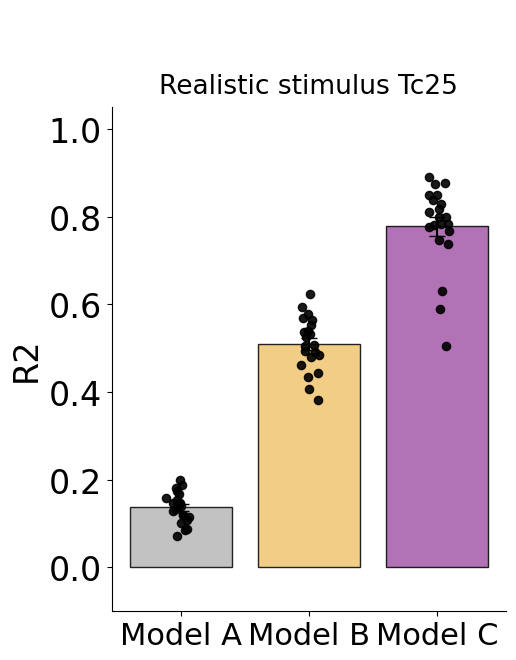

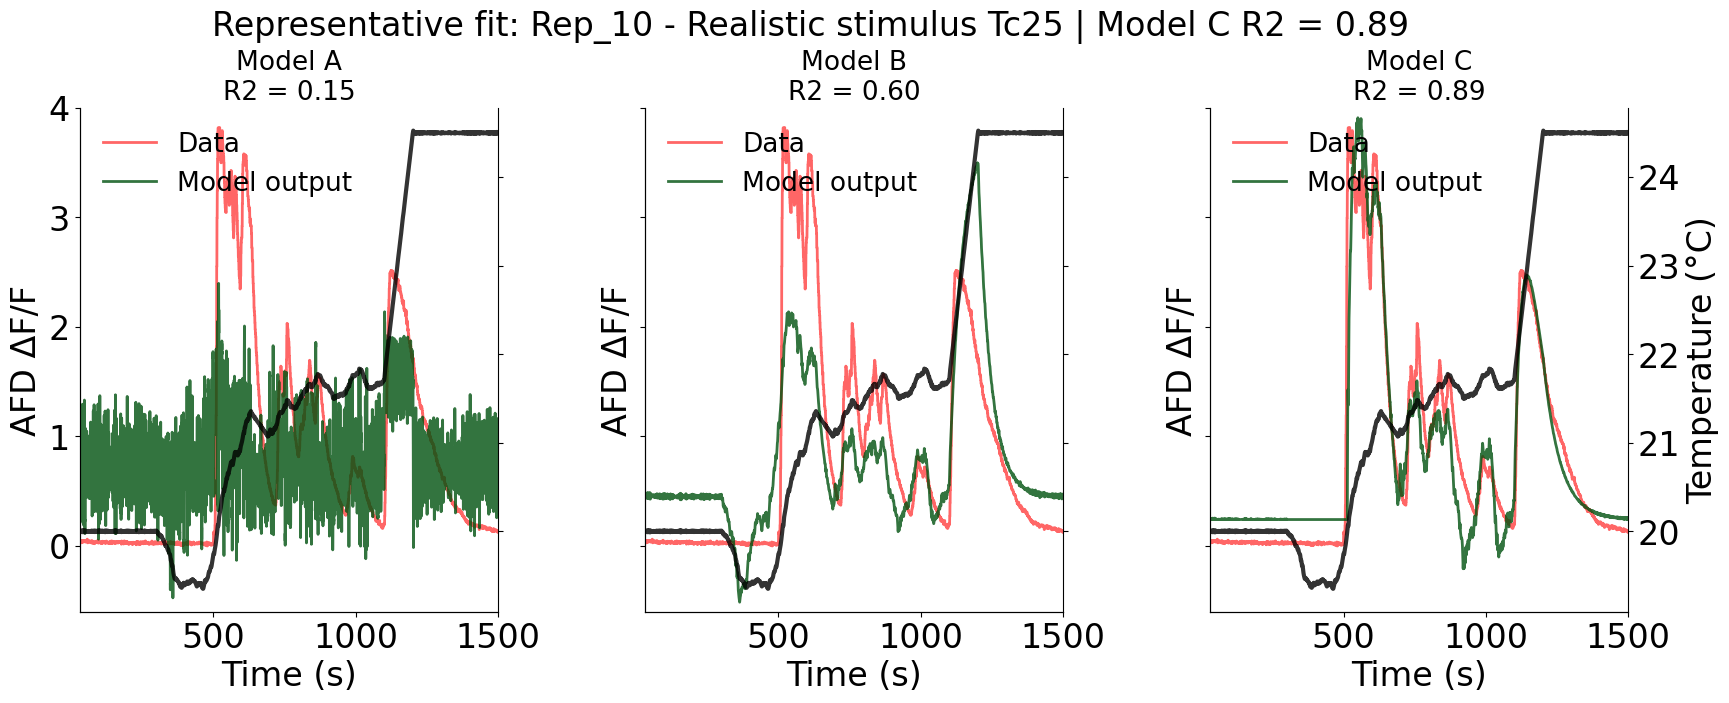

In [7]:
# ============================================================
# Visualizations: mean ± SEM R2 bars, plus representative timeseries
# PLUS parameter diagnostics (3 plots)
# UPDATED (your request):
#  - Parameter diagnostics now use FIXED axis limits equal to your Optuna ranges
#    so you can compare across conditions (Tc15/Tc20/Tc25, etc.)
#      * Violin plot: y-lims fixed to parameter range
#      * Param vs R2: x-lims fixed to parameter range (R2 y-lims unchanged)
#      * Pairplot: x/y-lims fixed to parameter ranges for all panels (including diagonal)
#  - Plot 1 + Plot 2 (parameter diagnostics) are SAVED (SVG) like others
#  - Pairplot is saved correctly (SAVE happens BEFORE plt.show so it never gets blank)
#  - No redundant imports, consistent RNG usage
#  - Preserves your locked-margin workflow for bar + timeseries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import pandas as pd
import seaborn as sns

# ---- Illustrator-safe SVG settings ----
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["svg.hashsalt"] = "0"

SAVE_FIGURES = False
SAVE_DIR = "path_to_save_figures"  # <-- UPDATE THIS PATH
FIGURE_PREFIX = "model"

BAR_YLIM = (-0.1, 1.05)

# ---- Colorblind-friendlier colors ----
DATA_COLOR = "#ff0101"   # Pink
FIT_COLOR  = "#00510f"   # Teal
TEMP_COLOR = "black"

DATA_ALPHA = 0.6
FIT_ALPHA  = 0.8
TEMP_ALPHA = 0.8

LINE_WIDTH = 2
TEMP_LINE_WIDTH = 1.5 * LINE_WIDTH

# ---- Match bar-plot size to timeseries panel geometry ----
PANEL_W = 5.8
PANEL_H = 7.0
BAR_W   = PANEL_W
BAR_H   = PANEL_H

# ---- Font sizes for bar + timeseries ----
SCALE = 1.2
TS_TITLE_FS   = int(round(16 * SCALE))
TS_LABEL_FS   = int(round(20 * SCALE))
TS_TICK_FS    = int(round(20 * SCALE))
TS_LEGEND_FS  = int(round(16 * SCALE))
SUPTITLE_FS   = int(round(20 * SCALE))

BAR_YTICK_FS  = TS_TICK_FS
BAR_YLABEL_FS = TS_LABEL_FS
BAR_TITLE_FS  = TS_TITLE_FS
BAR_XTICK_FS  = int(round(TS_TICK_FS * 0.9))  # only x-ticks smaller to prevent overlap

# ---- Parameter diagnostics font bump ----
P3_SCALE        = 1.45
P3_LABEL_FS     = int(round(16 * P3_SCALE))
P3_TICK_FS      = int(round(14 * P3_SCALE))
P3_TITLE_FS     = int(round(18 * P3_SCALE))
P3_SUPTITLE_FS  = int(round(20 * P3_SCALE))

# ---- Locked margins (critical for PPT/Illustrator matching) ----
TOP    = 0.88
BOTTOM = 0.16

LEFT_BAR  = 0.30
RIGHT_BAR = 0.98

LEFT_TS   = 0.08
RIGHT_TS  = 0.97
WSPACE_TS = 0.35

# ---- FIXED parameter ranges (match Optuna priors) ----
PARAM_RANGES = {
    "tauD":    (40.0, 60.0),
    "T_on":    (20.0, 21.0), #12 to 25
    "k_shape": (1.5, 8.0),
    "k_scale": (0.2, 5.0),
}

# ---- helpers ----
def mean_sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    if x.size == 1:
        return x[0], 0.0
    return x.mean(), x.std(ddof=1) / np.sqrt(x.size)

def _floor_half(x):
    return 0.5 * np.floor(x / 0.5)

def _ceil_half(x):
    return 0.5 * np.ceil(x / 0.5)

def compute_ylim_from_traces_strict(traces):
    """
    y-limits snapped to 0.5 grid with strict enclosure:
      lo = closest LOWER multiple of 0.5 BELOW min
      hi = closest HIGHER multiple of 0.5 ABOVE max
    """
    finite = []
    for t in traces:
        t = np.asarray(t, dtype=float)
        t = t[np.isfinite(t)]
        if t.size:
            finite.append(t)

    if not finite:
        return (-0.5, 0.5)

    vmin = float(min(np.min(v) for v in finite))
    vmax = float(max(np.max(v) for v in finite))

    lo = _floor_half(vmin)
    hi = _ceil_half(vmax)

    # strict enclosure if exactly on boundary
    if np.isclose(lo, vmin):
        lo -= 0.5
    if np.isclose(hi, vmax):
        hi += 0.5

    if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (hi <= lo):
        return (-0.5, 0.5)

    return (lo, hi)

def apply_pairplot_param_ranges(g, param_order, param_ranges):
    """
    Enforce fixed x/y limits on a seaborn pairplot grid, including diagonal.
    """
    for i, yvar in enumerate(param_order):
        for j, xvar in enumerate(param_order):
            ax = g.axes[i, j]
            if ax is None:
                continue
            if xvar in param_ranges:
                ax.set_xlim(param_ranges[xvar])
            if yvar in param_ranges:
                ax.set_ylim(param_ranges[yvar])

# Make sure save directory exists if saving
if SAVE_FIGURES:
    os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# A. Bar plot
# ============================================================

model_names = [cfg["name"] for cfg in stepwise_concepts]
concept_ids = [cfg["id"] for cfg in stepwise_concepts]

r2_arrays = [np.asarray(r2_by_concept[cid], dtype=float) for cid in concept_ids]
means = np.array([mean_sem(a)[0] for a in r2_arrays])
sems  = np.array([mean_sem(a)[1] for a in r2_arrays])

x = np.arange(len(concept_ids))
BAR_COLORS = ["#b8b8b8", "#f0c571", "#a559aa"][:len(concept_ids)]

fig_bar, ax = plt.subplots(figsize=(BAR_W, BAR_H))

ax.bar(
    x, means, yerr=sems, capsize=6,
    color=BAR_COLORS, edgecolor="black",
    linewidth=1.0, alpha=0.85, ecolor="black"
)

rng = np.random.default_rng(0)
for i, arr in enumerate(r2_arrays):
    v = arr[np.isfinite(arr)]
    jitter = rng.normal(0.0, 0.05, size=v.size)
    ax.scatter(np.full(v.size, x[i]) + jitter, v,
               color="black", s=35, alpha=0.9, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=BAR_XTICK_FS)
ax.set_ylabel("R2", fontsize=BAR_YLABEL_FS)
ax.set_title(f"{dataset}", fontsize=BAR_TITLE_FS, pad=10)
ax.tick_params(axis="y", labelsize=BAR_YTICK_FS)
ax.set_ylim(BAR_YLIM)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig_bar.suptitle(" ", fontsize=SUPTITLE_FS, y=1.02)
fig_bar.subplots_adjust(left=LEFT_BAR, right=RIGHT_BAR, bottom=BOTTOM, top=TOP)

if SAVE_FIGURES:
    save_path = os.path.join(SAVE_DIR, f"{FIGURE_PREFIX}_R2_{dataset}.svg")
    fig_bar.savefig(save_path, format="svg")
    print(f"Saved bar plot to: {save_path}")

plt.show()

# ============================================================
# B. Representative timeseries  (UPDATED: add per-model R2 in each panel title)
# ============================================================

if representative is None:
    print("No representative replicate available for timeseries plot.")
else:
    Time = np.asarray(Time_ramp, dtype=float)
    Temp = np.asarray(Temp_ramp, dtype=float)

    Calcium = np.asarray(representative["Calcium"], dtype=float)
    rep_name = str(representative["rep_name"])
    rep_results = representative["results"]

    # y_limits = compute_ylim_from_traces_strict([Calcium] + [r["fit"] for r in rep_results if "fit" in r])
    y_limits = (-0.6, 4.0)   # FIXED y-limits for consistency

    fig_ts, axes = plt.subplots(
        1, len(rep_results),
        figsize=(PANEL_W * len(rep_results), PANEL_H),
        sharey=True
    )
    if len(rep_results) == 1:
        axes = [axes]

    temp_axes = []

    for axC, res in zip(axes, rep_results):
        # ---- plot data + model fit ----
        axC.plot(Time, Calcium, color=DATA_COLOR, alpha=DATA_ALPHA,
                 linewidth=LINE_WIDTH, label="Data", zorder=2)

        axC.plot(Time, np.asarray(res["fit"], dtype=float),
                 color=FIT_COLOR, alpha=FIT_ALPHA,
                 linewidth=LINE_WIDTH, label="Model output", zorder=3)

        # ---- UPDATED: add R2 into panel title ----
        r2_txt = "R2 = n/a"
        if "R2" in res and np.isfinite(res["R2"]):
            r2_txt = f"R2 = {res['R2']:.2f}"

        axC.set_title(f"{res['name']}\n{r2_txt}", fontsize=TS_TITLE_FS)

        axC.set_xlabel("Time (s)", fontsize=TS_LABEL_FS)
        axC.set_ylabel("AFD ΔF/F", fontsize=TS_LABEL_FS)
        axC.tick_params(axis="both", labelsize=TS_TICK_FS)
        axC.set_xlim(Time[0], Time[-1])
        axC.set_ylim(y_limits)

        axC.spines["top"].set_visible(False)
        axC.spines["right"].set_visible(False)

        # ---- temperature overlay ----
        axT = axC.twinx()
        temp_axes.append(axT)
        axT.plot(Time, Temp, color=TEMP_COLOR, alpha=TEMP_ALPHA,
                 linewidth=TEMP_LINE_WIDTH, zorder=1)
        axT.tick_params(axis="y", labelsize=TS_TICK_FS, labelright=False)
        axT.spines["top"].set_visible(False)

        # ---- legend ----
        hC, lC = axC.get_legend_handles_labels()
        hT, lT = axT.get_legend_handles_labels()
        axC.legend(hC + hT, lC + lT,
                   fontsize=TS_LEGEND_FS, loc="upper left", frameon=False)

    temp_axes[-1].tick_params(axis="y", labelright=True, labelsize=TS_TICK_FS)
    temp_axes[-1].set_ylabel("Temperature (°C)", fontsize=TS_LABEL_FS)

    # ---- UPDATED: put overall full-model R2 in the suptitle too ----
    full_r2_txt = ""
    full_entry = next((r for r in rep_results if r.get("id") == "full_gamma"), None)
    if full_entry is not None and np.isfinite(full_entry.get("R2", np.nan)):
        full_r2_txt = f" | Model C R2 = {full_entry['R2']:.2f}"

    fig_ts.suptitle(
        f"Representative fit: {rep_name} - {dataset}{full_r2_txt}",
        fontsize=SUPTITLE_FS, y=1.02
    )

    fig_ts.subplots_adjust(
        left=LEFT_TS, right=RIGHT_TS,
        bottom=BOTTOM, top=TOP, wspace=WSPACE_TS
    )

    if SAVE_FIGURES:
        save_path = os.path.join(SAVE_DIR, f"{FIGURE_PREFIX}_fits_{dataset}_{rep_name}.svg")
        fig_ts.savefig(save_path, format="svg")
        print(f"Saved timeseries plot to: {save_path}")

    plt.show()

# ============================================================


Selected random worm/replicate: 17
LN-test points collected (worm 17): 14600


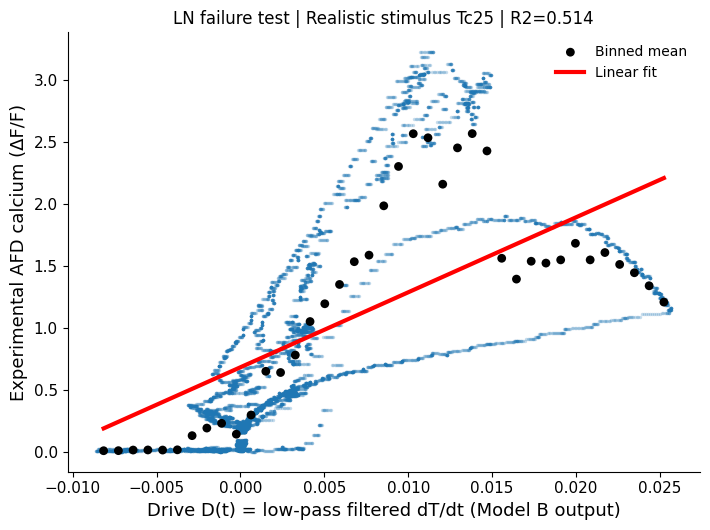

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# Single random worm (replicate): Calcium vs Drive D
# LN-style binned mean + linear fit
# Saves figure only if SAVE_FIGURES=True
# ============================================================

# ---------------- USER CONTROLS ----------------
USE_ALL_REPS = True
REP_TO_USE = 0

N_RANDOM_WORMS = 1
RANDOM_SEED = 0

DROP_INITIAL_SECONDS = 10.0

SUBSAMPLE_MAX_POINTS = 60000
SCATTER_S = 6
SCATTER_ALPHA = 0.25

# LN-style summary settings
N_D_BINS_LN = 40
MIN_POINTS_PER_BIN = 20
SUMMARY_POINT_SIZE = 40

# Figure saving
# ------------------------------------------------------------

# Safety checks
if "all_modelB_params" not in globals() or len(all_modelB_params) == 0:
    raise RuntimeError(
        "all_modelB_params is missing or empty."
    )

dfB = pd.DataFrame(all_modelB_params).copy()
if "tauD" not in dfB.columns:
    raise RuntimeError("tauD not found.")
if "rep_idx" not in dfB.columns:
    raise RuntimeError("rep_idx not found.")

Time = np.asarray(Time_ramp, dtype=float)
Temp = np.asarray(Temp_ramp, dtype=float)
t0 = float(Time[0])
mask0 = Time >= (t0 + float(DROP_INITIAL_SECONDS))

def compute_D_from_tau(Time, Temp, tauD):
    return model_2_derivative_with_tauD(Time, Temp, tauD)

# Decide reps
if USE_ALL_REPS:
    rep_indices = list(range(Ca_mat.shape[1]))
else:
    rep_indices = [int(REP_TO_USE)]

tauD_by_rep = {int(row["rep_idx"]): float(row["tauD"]) for _, row in dfB.iterrows()}

valid_reps = [r for r in rep_indices if r in tauD_by_rep]
if len(valid_reps) == 0:
    raise RuntimeError("No valid replicates found.")

# Pick random worm
rng = np.random.default_rng(RANDOM_SEED)
rep_idx = int(rng.choice(valid_reps, size=1, replace=False)[0])
print(f"Selected random worm/replicate: {rep_idx}")

# Data extraction
Calcium = np.asarray(Ca_mat[:, rep_idx], dtype=float)
tauD = float(tauD_by_rep[rep_idx])
D = compute_D_from_tau(Time, Temp, tauD)

m = mask0 & np.isfinite(D) & np.isfinite(Calcium)
if np.sum(m) < 20:
    raise RuntimeError("Too few valid points.")

D_all = D[m]
Ca_all = Calcium[m]

print(f"LN-test points collected (worm {rep_idx}): {len(D_all)}")

# Subsample for plotting
n = len(D_all)
if (SUBSAMPLE_MAX_POINTS is not None) and (n > SUBSAMPLE_MAX_POINTS):
    rng2 = np.random.default_rng(0)
    idx = rng2.choice(n, size=int(SUBSAMPLE_MAX_POINTS), replace=False)
    D_plot  = D_all[idx]
    Ca_plot = Ca_all[idx]
else:
    D_plot  = D_all
    Ca_plot = Ca_all

# -------------------------
# LN-style binning
# -------------------------
bins = np.linspace(np.nanmin(D_all), np.nanmax(D_all), int(N_D_BINS_LN))
bin_centers = 0.5 * (bins[:-1] + bins[1:])

Ca_mean = np.full(len(bin_centers), np.nan)
bin_counts = np.zeros(len(bin_centers), dtype=int)

for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    mk = (D_all >= lo) & (D_all < hi) & np.isfinite(Ca_all)
    bin_counts[k] = np.sum(mk)
    if bin_counts[k] >= MIN_POINTS_PER_BIN:
        Ca_mean[k] = np.nanmean(Ca_all[mk])

# Linear fit
fit_mask = np.isfinite(bin_centers) & np.isfinite(Ca_mean)

if np.sum(fit_mask) >= 2:
    x_fit = bin_centers[fit_mask]
    y_fit = Ca_mean[fit_mask]

    a, b = np.polyfit(x_fit, y_fit, deg=1)
    y_pred = a * x_fit + b

    ss_res = np.sum((y_fit - y_pred) ** 2)
    ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
    R2 = np.nan if ss_tot == 0 else (1.0 - ss_res / ss_tot)
else:
    a, b, R2 = np.nan, np.nan, np.nan

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 5.4))

# Scatter in standard matplotlib blue
ax.scatter(
    D_plot, Ca_plot,
    s=SCATTER_S,
    alpha=SCATTER_ALPHA,
    color="#1f77b4",
    linewidths=0
)

# Binned means
ax.scatter(
    bin_centers[fit_mask], Ca_mean[fit_mask],
    s=SUMMARY_POINT_SIZE,
    c="black",
    edgecolors="none",
    zorder=5,
    label="Binned mean"
)

# Linear fit
if np.isfinite(a):
    x_line = np.linspace(np.nanmin(x_fit), np.nanmax(x_fit), 200)
    y_line = a * x_line + b
    ax.plot(x_line, y_line, color="red", linewidth=3.0, label="Linear fit")

ax.set_xlabel("Drive D(t) = low-pass filtered dT/dt (Model B output)", fontsize=13)
ax.set_ylabel("Experimental AFD calcium (ΔF/F)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

# -------- Title (updated format) --------
r2_str = "NA" if not np.isfinite(R2) else f"{R2:.3f}"
ax.set_title(f"LN failure test | {dataset} | R2={r2_str}", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()

# -------------------------
# Save figure (same naming style as your pipeline)
# -------------------------
if SAVE_FIGURES:
    os.makedirs(SAVE_DIR, exist_ok=True)

    r2_tag = "NA" if not np.isfinite(R2) else f"{R2:.3f}"
    save_path = os.path.join(
        SAVE_DIR,
        f"{FIGURE_PREFIX}_R2_{dataset}_LNtest.svg"
    )

    fig.savefig(save_path, format="svg", bbox_inches="tight")
    print(f"Saved figure to: {save_path}")

plt.show()
